#### Bias Variance Tradeoff Analysis

### Problem Statement :---

To predict the price of the house using Bian Variance Tradeoff Analysis


A real estate company wants to predict house prices based on different features such as:

(a.)    Area

(b.)    Number of bedrooms

(c.)    Bathrooms

(d.)    Location factors

(e.)    Age of house

(f.)    Floors

(g.)    Garage


####  The main goal is to:

(a.)    Build machine learning models

(b.)    Understand underfitting and overfitting

(c.)    Analyze Bias-Variance Tradeoff

(d.)    Improve generalization performance

#### Step 1:  Import  all the necessary libraries

In [3229]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection     import  train_test_split, GridSearchCV, KFold
from    sklearn.preprocessing       import  StandardScaler
from    sklearn.pipeline            import  Pipeline
from    sklearn.linear_model        import  Ridge
from    sklearn.tree                import  DecisionTreeRegressor
from    sklearn.ensemble            import  RandomForestRegressor
from    sklearn.metrics             import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2:    Load the Dataset

In [3230]:
### load the data

df = pd.read_csv("Housing.csv")

In [3231]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#### OBSERVATIONS:

1.  The above dataset explains about the housing details of each and every customer along with their price.

2.  The independent features in the dataset ranges from area,.......,furnishingstatus.

3.  The dependent    feature in the dataset is the price of the house

#### Step 3:    Perform Data Exploration

In [3232]:
#### get the first five rows of the dataset

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3233]:
#### get the last five rows of the dataset

df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [3234]:
##### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 545


In [3235]:
#### Shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (545, 13)


In [3236]:
#### get the columns used in the dataset

df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [3237]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [3238]:
#### get the descriptive summary statistics for all the numerical columns

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


#### OBSERVATIONS:

1.  It explains about the descriptive statistical summary for each numerical column used in the dataset.

In [3239]:
#### get the descriptive summary statistics for all the categorical columns

df.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


#### OBSERVATIONS:

1.  It explains about the descriptive statistical summary for each categorical column used in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [3240]:
#### To check for the NULL records used in the dataset

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records used in the dataset.

In [3241]:
#### To check for the duplicate records used in the dataset

df[df.duplicated()]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

In [3242]:
#### Convert all the categorical values into the numeric values

df.head()

x = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea","furnishingstatus"]

#### perform label encoding on the above categorical columns

from  sklearn.preprocessing  import  LabelEncoder

#### create an object for Label Encoder

label = LabelEncoder()

for i in x:
    df[i]   =   label.fit_transform(df[i])

In [3243]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [3244]:
df['guestroom'].value_counts()

guestroom
0    448
1     97
Name: count, dtype: int64

In [3245]:
df['mainroad'].value_counts()

mainroad
1    468
0     77
Name: count, dtype: int64

In [3246]:
df['basement'].value_counts()

basement
0    354
1    191
Name: count, dtype: int64

In [3247]:
df['hotwaterheating'].value_counts()

hotwaterheating
0    520
1     25
Name: count, dtype: int64

In [3248]:
df['airconditioning'].value_counts()

airconditioning
0    373
1    172
Name: count, dtype: int64

In [3249]:
df['prefarea'].value_counts()

prefarea
0    417
1    128
Name: count, dtype: int64

In [3250]:
df['furnishingstatus'].value_counts()

furnishingstatus
1    227
2    178
0    140
Name: count, dtype: int64

#### OBSERVATIONS:

1.  All the categorical columns have been converted into the numerical values after performing the label encoding.

#### Step 5: Divide the dataset into independent and dependent features

In [3251]:
#### independent features

X = df.drop(columns='price',axis=1)

In [3252]:
print(X)

     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0    7420         4          2        3         1          0         0   
1    8960         4          4        4         1          0         0   
2    9960         3          2        2         1          0         1   
3    7500         4          2        2         1          0         1   
4    7420         4          1        2         1          1         1   
..    ...       ...        ...      ...       ...        ...       ...   
540  3000         2          1        1         1          0         1   
541  2400         3          1        1         0          0         0   
542  3620         2          1        1         1          0         0   
543  2910         3          1        1         0          0         0   
544  3850         3          1        2         1          0         0   

     hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
0                  0              

In [3253]:
#### dependent features

Y = df['price']

print(Y)

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64


#### Step 6:    Divide the independent and dependent variables into training and testing data

In [3254]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [3255]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,1,0,0,0,1,1,0,0
93,7200,3,2,1,1,0,1,0,1,3,0,1
335,3816,2,1,1,1,0,1,0,1,2,0,0
412,2610,3,1,2,1,0,1,0,0,0,1,2
471,3750,3,1,2,1,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,2
106,5450,4,2,1,1,0,1,0,1,0,1,1
270,4500,3,2,3,1,0,0,1,0,1,0,0
435,4040,2,1,1,1,0,0,0,0,0,0,2


In [3256]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,5900,4,2,2,0,0,1,0,0,1,0,2
77,6500,3,2,3,1,0,0,0,1,0,1,0
360,4040,2,1,1,1,0,0,0,0,0,0,1
90,5000,3,1,2,1,0,0,0,1,0,0,1
493,3960,3,1,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,1,0,1,0,0,2,0,1
357,6930,4,1,2,0,0,0,0,0,1,0,0
39,6000,4,2,4,1,0,0,0,1,1,0,1
54,6000,3,2,2,1,1,0,0,1,1,0,1


In [3257]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (436, 12)
Shape of the input testing  data is: (109, 12)


In [3258]:
Y_train

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
        ...   
71     6755000
106    6160000
270    4340000
435    3290000
102    6195000
Name: price, Length: 436, dtype: int64

In [3259]:
Y_test

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
        ...   
15     9100000
357    3773000
39     7910000
54     7350000
155    5530000
Name: price, Length: 109, dtype: int64

In [3260]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (436,)
Shape of the output testing  data is: (109,)


#### (a.) Ridge Regression (High Bias)


####  High Bias

    (a.)    Model is too simple to understand any complex patterns in the data

    (b.)    It leads to underfitting

    (c.)    It leads to poor training and testing performance.

EX ============>  Ridge Regression

In [3261]:
print("====================================Before Hyper Parameter Tuning===================================")

from    sklearn.preprocessing   import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_train_scaled

====================================Before Hyper Parameter Tuning===================================


array([[ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -1.40940148],
       [ 0.9291807 ,  0.05527092,  1.53917323, ...,  2.70998729,
        -0.55262032, -0.07931697],
       [-0.60775457, -1.28351359, -0.5579503 , ...,  1.53897197,
        -0.55262032, -1.40940148],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032,  1.25076755],
       [ 0.15707965,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.07931697]])

In [3262]:
X_test_scaled = sc.transform(X_test)

In [3263]:
X_test_scaled

array([[ 0.33875048,  1.39405543,  1.53917323, ...,  0.36795665,
        -0.55262032,  1.25076755],
       [ 0.61125674,  0.05527092,  1.53917323, ..., -0.80305867,
         1.80956067, -1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032, -0.07931697],
       ...,
       [ 0.38416819,  1.39405543,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.07931697],
       [ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.07931697],
       [ 0.4295859 ,  0.05527092,  1.53917323, ...,  1.53897197,
         1.80956067, -1.40940148]])

In [3264]:
#### Train the Ridge Regression Model

from    sklearn.linear_model  import  Ridge

#### create an object for Ridge Regression

ridge = Ridge(alpha=0.1)

#### using the object for Ridge Regression, train the model

ridge.fit(X_train_scaled, Y_train)

Ridge(alpha=0.1)

In [3265]:
#### predict the model

Y_pred_ridge = ridge.predict(X_test_scaled)

In [3266]:
Y_pred_ridge

array([5203507.063658  , 7256577.26230002, 3062983.89654945,
       4559641.12517682, 3333209.89654651, 3563219.48698322,
       5645471.05270151, 6413892.97106666, 2756057.07369427,
       2669202.69857508, 9569913.51862456, 2827588.72523915,
       3195696.61704477, 3352296.52770861, 3713941.13142618,
       5300884.92707306, 2988081.52678613, 4810812.67601231,
       4383017.66117169, 3525153.43517407, 5796014.95855357,
       5839925.78836607, 2760385.50151057, 4762662.94253438,
       5204750.70948231, 7515033.66943727, 3254856.68244129,
       5236163.9917417 , 8177988.17223865, 3434282.59989767,
       6443586.35157254, 3346238.94652221, 6742122.47553041,
       4154991.92431818, 3589407.96649519, 5787999.66248591,
       4768526.106225  , 4391815.75461928, 3217794.20334085,
       4638344.37948038, 4522270.87204183, 3541372.75524926,
       7237713.19949901, 4021704.37053373, 3702004.02393349,
       4298874.57937448, 6704612.17090618, 3993746.20253937,
       3798144.75635084,

In [3267]:
#### Evaluate the Regression Metrics

from sklearn.metrics  import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("=========================Mean Absolute Error===========================================")

maeridge = mean_absolute_error(Y_test, Y_pred_ridge)

print("Mean Absolute Error of the model is:", maeridge)



print("=========================Mean Squared Error===========================================")

mseridge = mean_squared_error(Y_test, Y_pred_ridge)

print("Mean Squared Error of the model is:", mseridge)


print("=========================Root Mean Squared Error===========================================")

rmseridge = root_mean_squared_error(Y_test, Y_pred_ridge)

print("Root Mean Squared Error of the model is:", rmseridge)


print("=========================R2 Score===========================================")

r2ridge = r2_score(Y_test, Y_pred_ridge)

print("R2 Score of the model is:", r2ridge)

=========================Mean Absolute Error===========================================
Mean Absolute Error of the model is: 979666.5287590962
=========================Mean Squared Error===========================================
Mean Squared Error of the model is: 1771808783138.1958
=========================Root Mean Squared Error===========================================
Root Mean Squared Error of the model is: 1331093.078315035
=========================R2 Score===========================================
R2 Score of the model is: 0.6494640104340739


#### OBSERVATIONS:

1.  The R2 Score of the Ridge Regression for the Housing Dataset is 0.64, which is fine. But it can further be improved using Hyper Parameter Tuning using GridSearch CV.

In [3268]:
print("====================================After Hyper Parameter Tuning===================================")


#### define the pipeline

from  sklearn.pipeline  import  Pipeline

#### create an object for pipeline

pipeline = Pipeline([
    ("sc"       ,       StandardScaler())               ,
    ("ridge"    ,       Ridge())
])

====================================After Hyper Parameter Tuning===================================


In [3269]:
#### define the param grid

param_grid = {
    "ridge__alpha"      :   [0.01,  0.1,    1,  10, 100,1000]
}

In [3270]:
#### perform the KFold Validation

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [3271]:
#### Create an object for GridSearchCV

gridridge = GridSearchCV(
    pipeline                        ,
    param_grid  =   param_grid      ,
    cv          =       cv          ,
    scoring     =     'r2'          ,
    n_jobs      =     -1   
)

In [3272]:
#### using the object for GridSearchCV, train the model

gridridge.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
             scoring='r2')

In [3273]:
#### Obtain the best parameters and the estimators for the model

best_parameter_ridge = gridridge.best_params_

print("Best Parameters for this model is:", best_parameter_ridge)


best_estimator_ridge = gridridge.best_estimator_

print("Best Estimator for this model is:", best_estimator_ridge)

Best Parameters for this model is: {'ridge__alpha': 10}
Best Estimator for this model is: Pipeline(steps=[('sc', StandardScaler()), ('ridge', Ridge(alpha=10))])


In [3274]:
#### predict the model

Y_pred_grid_ridge = best_estimator_ridge.predict(X_test)

In [3275]:
Y_pred_grid_ridge

array([5186078.49228468, 7215424.63436571, 3078154.87651011,
       4564276.36267827, 3359757.85705382, 3576607.92146009,
       5645455.60222503, 6405077.05048196, 2777902.87179176,
       2694752.0227472 , 9503465.29446023, 2843010.90212358,
       3197099.8043578 , 3356094.61027054, 3720294.56045208,
       5281326.70136989, 3003946.25786594, 4811920.14880486,
       4382034.14539347, 3531314.53526903, 5772707.35418599,
       5832334.89482507, 2777117.78847751, 4769574.85659592,
       5204265.00850656, 7466253.50180209, 3271884.98967863,
       5235969.77342821, 8126535.84227654, 3445786.52558435,
       6411381.18461757, 3368797.4458539 , 6722234.26601742,
       4160415.22407493, 3613826.60698904, 5775581.1678268 ,
       4783337.39322841, 4404361.85572548, 3231073.79950835,
       4652176.08857165, 4532713.68270606, 3549980.36349883,
       7196928.3217633 , 4039770.38636305, 3704717.46591658,
       4298421.41376399, 6667085.10501831, 4020326.6784457 ,
       3794646.18551731,

In [3276]:
#### Evaluate the Regression Metrics ater performing Hyper Parameter Tuning

from sklearn.metrics  import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("=========================Mean Absolute Error===========================================")

maegridridge = mean_absolute_error(Y_test, Y_pred_grid_ridge)

print("Mean Absolute Error of the model is:", maegridridge)



print("=========================Mean Squared Error===========================================")

msegridridge = mean_squared_error(Y_test, Y_pred_grid_ridge)

print("Mean Squared Error of the model is:", msegridridge)


print("=========================Root Mean Squared Error===========================================")

rmsegridridge = root_mean_squared_error(Y_test, Y_pred_grid_ridge)

print("Root Mean Squared Error of the model is:", rmsegridridge)


print("=========================R2 Score===========================================")

r2gridridge = r2_score(Y_test, Y_pred_grid_ridge)

print("R2 Score of the model is:", r2gridridge)

=========================Mean Absolute Error===========================================
Mean Absolute Error of the model is: 978653.4031173647
=========================Mean Squared Error===========================================
Mean Squared Error of the model is: 1778081197208.694
=========================Root Mean Squared Error===========================================
Root Mean Squared Error of the model is: 1333447.1107654378
=========================R2 Score===========================================
R2 Score of the model is: 0.648223071290926


#### OBSERVATIONS:

1.  The R2 Score of Ridge Rgression for Housing dataset remains the same as 0.6482 even after performing Hyper Parameter Tuning the model withn GridSearch CV.

####   CONCLUSIONS  FOR HIGH BIAS


1.  If the model has high bias ====================> Model is too simple to understand any patterns in the data

2.  It leads to underfitting

3.  It leads to poor training and testing performance.

EX ============>  Ridge Regression

#### (a.) Decision Tree Regression (High Variance)


####  High Variance

    (a.)    Model is too complex that it learns patterns as well as the noise from it

    (b.)    It leads to overfitting

    (a.)    It leads to high training performance but poor testing performance.


EX ============>  Decision Tree Regression

In [3277]:
print("====================================Before Hyper Parameter Tuning===================================")

from    sklearn.preprocessing   import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled_dectree = sc.fit_transform(X_train)

X_train_scaled_dectree

====================================Before Hyper Parameter Tuning===================================


array([[ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -1.40940148],
       [ 0.9291807 ,  0.05527092,  1.53917323, ...,  2.70998729,
        -0.55262032, -0.07931697],
       [-0.60775457, -1.28351359, -0.5579503 , ...,  1.53897197,
        -0.55262032, -1.40940148],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032,  1.25076755],
       [ 0.15707965,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.07931697]])

In [3278]:
X_test_scaled_dectree = sc.transform(X_test)

In [3279]:
X_test_scaled_dectree

array([[ 0.33875048,  1.39405543,  1.53917323, ...,  0.36795665,
        -0.55262032,  1.25076755],
       [ 0.61125674,  0.05527092,  1.53917323, ..., -0.80305867,
         1.80956067, -1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032, -0.07931697],
       ...,
       [ 0.38416819,  1.39405543,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.07931697],
       [ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.07931697],
       [ 0.4295859 ,  0.05527092,  1.53917323, ...,  1.53897197,
         1.80956067, -1.40940148]])

In [3280]:
#### Train the Decision Tree Regression Model

from    sklearn.tree  import  DecisionTreeRegressor

#### create an object for Ridge Regression

dectree = DecisionTreeRegressor(random_state = 42)

#### using the object for Ridge Regression, train the model

dectree.fit(X_train_scaled_dectree, Y_train)

DecisionTreeRegressor(random_state=42)

In [3281]:
#### predict the model

Y_pred_dectree = dectree.predict(X_test_scaled_dectree)

In [3282]:
Y_pred_dectree

array([ 5250000.,  7840000.,  3850000.,  4900000.,  2660000.,  3500000.,
        7070000.,  4893000.,  2380000.,  2940000., 10150000.,  3255000.,
        2957500.,  3640000.,  2653000.,  4200000.,  3850000.,  4270000.,
        3640000.,  3710000.,  6160000.,  5950000.,  2957500.,  3430000.,
        6020000.,  6790000.,  3150000.,  3885000.,  7000000.,  2961000.,
        6615000.,  2450000.,  7560000.,  4235000.,  2870000.,  6405000.,
        4900000.,  4200000.,  3115000.,  3885000.,  3920000.,  2870000.,
        7840000.,  4480000.,  4270000.,  4200000.,  7560000.,  4480000.,
        2450000.,  3430000.,  8960000.,  1855000.,  3920000.,  4900000.,
        3500000.,  2940000.,  8295000.,  2800000.,  5040000.,  3255000.,
        2590000.,  3430000.,  4200000.,  4200000.,  4403000.,  4550000.,
        5950000.,  2100000.,  4795000.,  3395000.,  3885000.,  5873000.,
        8400000.,  9100000.,  3290000.,  4025000.,  4550000.,  3010000.,
        3710000.,  5600000.,  8855000.,  4480000., 

In [3283]:
#### Evaluate the Regression Metrics

from sklearn.metrics  import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("=========================Mean Absolute Error===========================================")

maedectree = mean_absolute_error(Y_test, Y_pred_dectree)

print("Mean Absolute Error of the model is:", maedectree)



print("=========================Mean Squared Error===========================================")

msedectree = mean_squared_error(Y_test, Y_pred_dectree)

print("Mean Squared Error of the model is:", msedectree)


print("=========================Root Mean Squared Error===========================================")

rmsedectree = root_mean_squared_error(Y_test, Y_pred_dectree)

print("Root Mean Squared Error of the model is:", rmsedectree)


print("=========================R2 Score===========================================")

r2dectree = r2_score(Y_test, Y_pred_dectree)

print("R2 Score of the model is:", r2dectree)

=========================Mean Absolute Error===========================================
Mean Absolute Error of the model is: 1222399.0825688073
=========================Mean Squared Error===========================================
Mean Squared Error of the model is: 2688177649082.569
=========================Root Mean Squared Error===========================================
Root Mean Squared Error of the model is: 1639566.2990811225
=========================R2 Score===========================================
R2 Score of the model is: 0.4681689010023007


#### OBSERVATIONS:

1.  The R2 Score of the Ridge Regression for the Housing Dataset is 0.46, which is low. But it can further be improved using Hyper Parameter Tuning using GridSearch CV.

In [3284]:
print("====================================After Hyper Parameter Tuning===================================")


#### define the pipeline

from  sklearn.pipeline  import  Pipeline

#### create an object for pipeline

pipeline = Pipeline([
    ("sc"         ,       StandardScaler())               ,
    ("dectree"    ,       DecisionTreeRegressor())
])

====================================After Hyper Parameter Tuning===================================


In [3285]:
#### define the parameter grid

param_grid = {
    "dectree__criterion"         :   ["squared_error"    ,   "friedman_mse"]         ,
    "dectree__max_depth"         :   [3,5,10,15,20]                                  ,
    "dectree__min_samples_split" :   [2,5,10]                                        ,
    "dectree__min_samples_leaf"  :   [1,2,4]                                         ,
    "dectree__max_features"      :   [None,"sqrt","log2"]    
}

In [3286]:
#### perform the KFold validation

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [3287]:
#### Create an object for GridSearchCV

griddectree = GridSearchCV(
    pipeline                        ,
    param_grid  =   param_grid      ,
    cv          =       cv          ,
    scoring     =     'r2'          ,
    n_jobs      =     -1   
)

In [3288]:
#### using the object for GridSearchCV, train the model

griddectree.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('dectree', DecisionTreeRegressor())]),
             n_jobs=-1,
             param_grid={'dectree__criterion': ['squared_error',
                                                'friedman_mse'],
                         'dectree__max_depth': [3, 5, 10, 15, 20],
                         'dectree__max_features': [None, 'sqrt', 'log2'],
                         'dectree__min_samples_leaf': [1, 2, 4],
                         'dectree__min_samples_split': [2, 5, 10]},
             scoring='r2')

In [3289]:
#### Obtain the best parameters and the estimators for the model

best_parameter_dectree = griddectree.best_params_

print("Best Parameters for this model is:", best_parameter_dectree)


best_estimator_dectree = griddectree.best_estimator_

print("Best Estimator for this model is:", best_estimator_dectree)

Best Parameters for this model is: {'dectree__criterion': 'squared_error', 'dectree__max_depth': 5, 'dectree__max_features': None, 'dectree__min_samples_leaf': 4, 'dectree__min_samples_split': 2}
Best Estimator for this model is: Pipeline(steps=[('sc', StandardScaler()),
                ('dectree',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=4))])


In [3290]:
#### predict the model

Y_pred_grid_dectree = best_estimator_dectree.predict(X_test)

In [3291]:
#### Evaluate the Regression Metrics ater performing Hyper Parameter Tuning

from sklearn.metrics  import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("=========================Mean Absolute Error===========================================")

maegriddectree = mean_absolute_error(Y_test, Y_pred_grid_dectree)

print("Mean Absolute Error of the model is:", maegriddectree)



print("=========================Mean Squared Error===========================================")

msegriddectree = mean_squared_error(Y_test, Y_pred_grid_dectree)

print("Mean Squared Error of the model is:", msegriddectree)


print("=========================Root Mean Squared Error===========================================")

rmsegriddectree = root_mean_squared_error(Y_test, Y_pred_grid_dectree)

print("Root Mean Squared Error of the model is:", rmsegriddectree)


print("=========================R2 Score===========================================")

r2griddectree = r2_score(Y_test, Y_pred_grid_dectree)

print("R2 Score of the model is:", r2griddectree)

=========================Mean Absolute Error===========================================
Mean Absolute Error of the model is: 1207548.5467682374
=========================Mean Squared Error===========================================
Mean Squared Error of the model is: 2597777774930.716
=========================Root Mean Squared Error===========================================
Root Mean Squared Error of the model is: 1611762.3196149971
=========================R2 Score===========================================
R2 Score of the model is: 0.48605368046836084


#### OBSERVATIONS:

1.  The R2 Score of the Decision Tree Regression for the Housing Dataset is 0.51, which is low. But it can further be improved using Hyper Parameter Tuning using GridSearch CV.

2.  But after performing Hyper Parameter Tuning using GridSearch CV, the ccuracy has increased from 0.46 to 0.48.

3. So the model is working fine.



####   CONCLUSIONS  FOR HIGH VARIANCE


1.  If the model has high variance ====================> Model is too complex that it can understand patterns as wellas the noise from the data

2.  It leads to overfitting

3.  It leads to high training performance but poor testing performance.


EX =  Decision Tree Regressor

####    BIAS    VARIANCE TRADEOFF

It refers to the technique of creating a generalized model in such a manner that the model has a very high training accuracy and also a very high testing accuracy.

(a.)    Here neither overfitting nor underfitting occurs.

(b.)    High training performance and high testing performance.


EX ================>   Random Forest Regressor

In [3292]:
print("====================================Before Hyper Parameter Tuning===================================")

from    sklearn.preprocessing   import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled_rantree = sc.fit_transform(X_train)

X_train_scaled_rantree

====================================Before Hyper Parameter Tuning===================================


array([[ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -1.40940148],
       [ 0.9291807 ,  0.05527092,  1.53917323, ...,  2.70998729,
        -0.55262032, -0.07931697],
       [-0.60775457, -1.28351359, -0.5579503 , ...,  1.53897197,
        -0.55262032, -1.40940148],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032,  1.25076755],
       [ 0.15707965,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.07931697]])

In [3293]:
X_test_scaled_rantree = sc.transform(X_test)

In [3294]:
X_test_scaled_rantree

array([[ 0.33875048,  1.39405543,  1.53917323, ...,  0.36795665,
        -0.55262032,  1.25076755],
       [ 0.61125674,  0.05527092,  1.53917323, ..., -0.80305867,
         1.80956067, -1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032, -0.07931697],
       ...,
       [ 0.38416819,  1.39405543,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.07931697],
       [ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.07931697],
       [ 0.4295859 ,  0.05527092,  1.53917323, ...,  1.53897197,
         1.80956067, -1.40940148]])

In [3295]:
#### Train the Random Tree Regression Model

from    sklearn.ensemble  import  RandomForestRegressor

#### create an object for Ridge Regression

rantree = RandomForestRegressor(n_estimators = 100, random_state = 42)

#### using the object for Ridge Regression, train the model

rantree.fit(X_train_scaled_rantree, Y_train)

RandomForestRegressor(random_state=42)

In [3296]:
#### predict the model

Y_pred_rantree = rantree.predict(X_test_scaled_rantree)

In [3297]:
Y_pred_rantree

array([5223575.        , 7425040.        , 3776158.75      ,
       4526620.        , 3733800.        , 3488380.        ,
       5106360.        , 5199390.        , 2561930.        ,
       2878067.5       , 9911609.4       , 3358267.5       ,
       2983913.33333333, 3509240.        , 3641225.        ,
       3849860.        , 3332756.        , 5001850.        ,
       3632790.        , 4080825.        , 5340930.        ,
       5893720.        , 3077981.66666667, 3637410.        ,
       4740260.        , 6585670.        , 3134250.        ,
       4727030.        , 6484030.        , 3283490.        ,
       5738740.        , 3145240.        , 6910260.        ,
       4339790.        , 2971220.        , 6170780.        ,
       4828810.        , 3743915.        , 3058545.        ,
       4345670.        , 4126080.        , 2801225.        ,
       7582190.        , 4224850.        , 4022060.        ,
       4398065.        , 7171424.4       , 4080160.        ,
       3052490.        ,

In [3298]:
#### Evaluate the Regression Metrics

from sklearn.metrics  import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("=========================Mean Absolute Error===========================================")

maerantree = mean_absolute_error(Y_test, Y_pred_rantree)

print("Mean Absolute Error of the model is:", maerantree)



print("=========================Mean Squared Error===========================================")

mserantree = mean_squared_error(Y_test, Y_pred_rantree)

print("Mean Squared Error of the model is:", mserantree)


print("=========================Root Mean Squared Error===========================================")

rmserantree = root_mean_squared_error(Y_test, Y_pred_rantree)

print("Root Mean Squared Error of the model is:", rmserantree)


print("=========================R2 Score===========================================")

r2rantree = r2_score(Y_test, Y_pred_rantree)

print("R2 Score of the model is:", r2rantree)

=========================Mean Absolute Error===========================================
Mean Absolute Error of the model is: 1026699.6876146789
=========================Mean Squared Error===========================================
Mean Squared Error of the model is: 1962144940711.022
=========================Root Mean Squared Error===========================================
Root Mean Squared Error of the model is: 1400765.8407853262
=========================R2 Score===========================================
R2 Score of the model is: 0.6118077610803518


#### OBSERVATIONS:

1.  The R2 Score of the Random Forest Regression for the Housing Dataset is 0.61, which is high. But it can further be improved using Hyper Parameter Tuning using GridSearch CV.

In [3299]:
print("====================================After Hyper Parameter Tuning===================================")


#### define the pipeline

from  sklearn.pipeline  import  Pipeline

#### create an object for Pipeline

pipeline = Pipeline([
    ("sc"           ,           StandardScaler())                   ,
    ("rantree"      ,           RandomForestRegressor())
])

====================================After Hyper Parameter Tuning===================================


In [3300]:
#### define the param grid

param_grid = {
    "rantree__n_estimators"      :       [500,700]           ,
    "rantree__max_depth"         :       [5,10,15,None]      ,
    "rantree__min_samples_split" :       [2,5,10]            ,
    "rantree__min_samples_leaf"  :       [1,2,4]             ,
    "rantree__max_features"      :       ['sqrt','log2']
}

In [3301]:
#### perform the KFold Validation

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [3302]:
#### create the object for GridSearchCV

gridrantree = GridSearchCV(
    pipeline                                                ,
    param_grid              =           param_grid          ,
     cv                     =              cv               ,
     scoring                =            'r2'               ,
     n_jobs                 =               -1  
)

In [3303]:
#### using the object of GridSearchCV, train the model

gridrantree.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('rantree', RandomForestRegressor())]),
             n_jobs=-1,
             param_grid={'rantree__max_depth': [5, 10, 15, None],
                         'rantree__max_features': ['sqrt', 'log2'],
                         'rantree__min_samples_leaf': [1, 2, 4],
                         'rantree__min_samples_split': [2, 5, 10],
                         'rantree__n_estimators': [500, 700]},
             scoring='r2')

In [3304]:
#### Obtain the best parameters and the estimators for the model

best_parameter_rantree = gridrantree.best_params_

print("Best Parameters for this model is:", best_parameter_rantree)


best_estimator_rantree = gridrantree.best_estimator_

print("Best Estimator for this model is:", best_estimator_rantree)

Best Parameters for this model is: {'rantree__max_depth': 10, 'rantree__max_features': 'log2', 'rantree__min_samples_leaf': 1, 'rantree__min_samples_split': 2, 'rantree__n_estimators': 500}
Best Estimator for this model is: Pipeline(steps=[('sc', StandardScaler()),
                ('rantree',
                 RandomForestRegressor(max_depth=10, max_features='log2',
                                       n_estimators=500))])


In [3305]:
#### predict the model

Y_pred_grid_rantree = best_estimator_rantree.predict(X_test)

In [3306]:
Y_pred_grid_rantree

array([5492158.38181818, 7141280.89945947, 3671321.04350613,
       4593428.77667118, 3799523.60387752, 3681592.53351643,
       5266983.71217531, 5299057.90395577, 2949209.03255975,
       2822849.80181183, 8550738.77813131, 3109971.66342198,
       3078413.87925747, 3472380.52543962, 3633905.74317025,
       4393635.00512821, 3348764.43339455, 5216936.15682788,
       4102340.4076739 , 3994189.68705416, 5630448.71666667,
       6024775.35282968, 2949336.48521695, 4210473.1161513 ,
       5088267.47367627, 6722940.59959111, 3742185.34363577,
       4669980.83241813, 6468406.87929293, 3442697.16395395,
       5652072.80604118, 3234082.87255475, 6659092.49339213,
       4429801.07560948, 3215998.88889735, 6097760.26572865,
       4782207.566676  , 3903319.4097993 , 3105798.84561861,
       4453823.3576692 , 4664900.51158134, 2982063.36403926,
       7247489.14188372, 4223723.498776  , 3829382.08551503,
       4252078.50649263, 6751513.21070876, 4178303.48643625,
       3008131.70240178,

In [3307]:
#### Evaluate the Regression Metrics ater performing Hyper Parameter Tuning

from sklearn.metrics  import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("=========================Mean Absolute Error===========================================")

maegridrantree = mean_absolute_error(Y_test, Y_pred_grid_rantree)

print("Mean Absolute Error of the model is:", maegriddectree)



print("=========================Mean Squared Error===========================================")

msegridrantree = mean_squared_error(Y_test, Y_pred_grid_rantree)

print("Mean Squared Error of the model is:", msegridrantree)


print("=========================Root Mean Squared Error===========================================")

rmsegridrantree = root_mean_squared_error(Y_test, Y_pred_grid_rantree)

print("Root Mean Squared Error of the model is:", rmsegridrantree)


print("=========================R2 Score===========================================")

r2gridrantree = r2_score(Y_test, Y_pred_grid_rantree)

print("R2 Score of the model is:", r2gridrantree)

=========================Mean Absolute Error===========================================
Mean Absolute Error of the model is: 1207548.5467682374
=========================Mean Squared Error===========================================
Mean Squared Error of the model is: 1889404741617.8271
=========================Root Mean Squared Error===========================================
Root Mean Squared Error of the model is: 1374556.1980573318
=========================R2 Score===========================================
R2 Score of the model is: 0.6261987370778825


#### OBSERVATIONS:

1.  The R2 Score of the Random Tree Regression for the Housing Dataset is 0.61, which is low. But it can further be improved using Hyper Parameter Tuning using GridSearch CV.

2.  But after performing Hyper Parameter Tuning using GridSearch CV, the ccuracy has increased from 0.61 to 0.63

3. So the model is working fine.



####   CONCLUSIONS  FOR BIAS VARIANCE TRADEOFF


1.	It refers to the technique of creating a generalized model in such a manner that the model has a very high training accuracy and also a very high testing accuracy.

	(a.)    Here neither overfitting nor underfitting occurs.

	(b.)    High training performance and high testing performance.


EX ================>   Random Forest Regressor

#### (b.) Compare Diferent Models

In [3308]:
results = pd.DataFrame({
    'Models':["Ridge    Regression"    ,
              "Decision Tree      "    ,
              "Random   Forest"]       ,
              
    'R2 Score':[r2gridridge            ,
                r2griddectree          ,
                r2gridrantree]
})

In [3309]:
results

,Models,R2 Score
0,Ridge Regression,0.648223
1,Decision Tree,0.486054
2,Random Forest,0.626199


#### (c.)  Visualize Model Performance

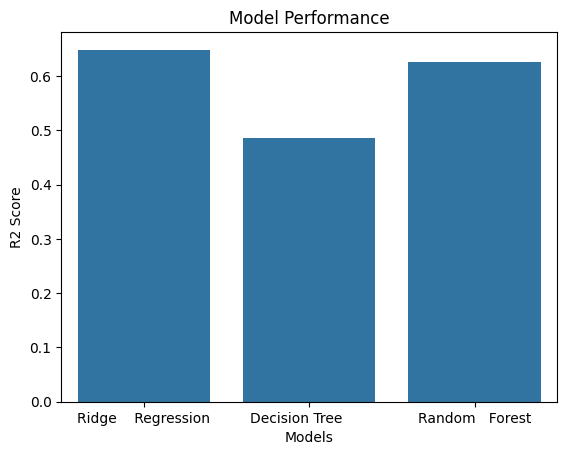

In [3310]:
sns.barplot(x="Models", y="R2 Score", data = results)

plt.title("Model Performance")

plt.show()